# Blood Cancer Model — Evaluation

Standalone notebook: mounts Drive, loads the **test set** and the saved `best_model.pth` checkpoint from the Training notebook, and reports test metrics (accuracy, classification report, confusion matrix, recall, F1).

This does **not** re-run training — it only needs the checkpoint file to already exist from having run the Training notebook at least once.

## Setup

In [ ]:
# Connect with google drive
import os
from google.colab import drive

# Use force_remount=True to bypass caching issues
drive.mount('/content/drive', force_remount=True)


In [ ]:
# Import basic libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# Import PyTorch libraries
import torch
import torch.nn as nn

# Import torchvision libraries
from torchvision import datasets, transforms, models

# Import DataLoader
from torch.utils.data import DataLoader

# Import evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Import seaborn
import seaborn as sns


In [ ]:
# Check GPU availability
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


In [ ]:
# Define dataset path (must match the Training notebook)
dataset_path = "/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/final_dataset"

# Define test path
test_dir = dataset_path + "/test"

# Define checkpoint path (where Training notebook saved best_model.pth)
checkpoint_path = "/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/final_dataset/checkpoints"


In [ ]:
# Test transformations (must match the Training notebook's val_test_transforms)
val_test_transforms = transforms.Compose([

    # Resize images
    transforms.Resize((224, 224)),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize images
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
# Load test dataset
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transforms
)

# Create test dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)


In [ ]:
# Get class names directly from the test set folder structure
# (identical class list/order to the training set, since ImageFolder
# sorts class folder names alphabetically either way)
class_names = test_dataset.classes

print(class_names)


## Load the trained model and evaluate on the test set

In [28]:
# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Get input features
num_features = model.fc.in_features

# Recreate final layer
model.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(num_features, 256),

    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(256, len(class_names))
)

# Move model to GPU
model = model.to(device)

In [29]:
# Load best model
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/7.ADL & Computer Vision/Code Folder/blood_cancer_dataset/final_dataset/checkpoints/best_model.pth")
)

<All keys matched successfully>

In [30]:
# Set model to evaluation mode
model.eval()

# Store predictions and labels
all_predictions = []
all_labels = []

# Disable gradients
with torch.no_grad():

    # Test loop
    for images, labels in test_loader:

        # Move images to GPU
        images = images.to(device)

        # Forward pass
        outputs = model(images)

        # Get predictions
        _, predicted = torch.max(outputs, 1)

        # Store predictions
        all_predictions.extend(
            predicted.cpu().numpy()
        )

        # Store labels
        all_labels.extend(
            labels.numpy()
        )

In [31]:
# Variables for accuracy
correct = 0
total = 0

# Store predictions
all_predictions = []
all_labels = []

# Disable gradients
with torch.no_grad():

    # Loop through test data
    for images, labels in test_loader:

        # Move images to GPU
        images = images.to(device)

        # Move labels to GPU
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predictions
        _, predicted = torch.max(outputs, 1)

        # Count total labels
        total += labels.size(0)

        # Count correct predictions
        correct += (predicted == labels).sum().item()

        # Store predictions
        all_predictions.extend(
            predicted.cpu().numpy()
        )

        # Store true labels
        all_labels.extend(
            labels.cpu().numpy()
        )

# Calculate accuracy
test_accuracy = correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8115942028985508


In [32]:
# Print classification report
print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
))

              precision    recall  f1-score   support

         BAS       0.00      0.00      0.00        12
         EBO       0.38      0.25      0.30        12
         EOS       0.51      0.61      0.56        64
         LYT       0.80      0.76      0.78       591
         MON       0.54      0.80      0.64       269
         MYB       0.00      0.00      0.00         7
         MYO       0.85      0.72      0.78       491
         NGB       0.00      0.00      0.00        17
         NGS       0.91      0.92      0.92      1273
       OTHER       0.00      0.00      0.00        13
         PMO       0.33      0.09      0.14        11

    accuracy                           0.81      2760
   macro avg       0.39      0.38      0.37      2760
weighted avg       0.81      0.81      0.81      2760



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


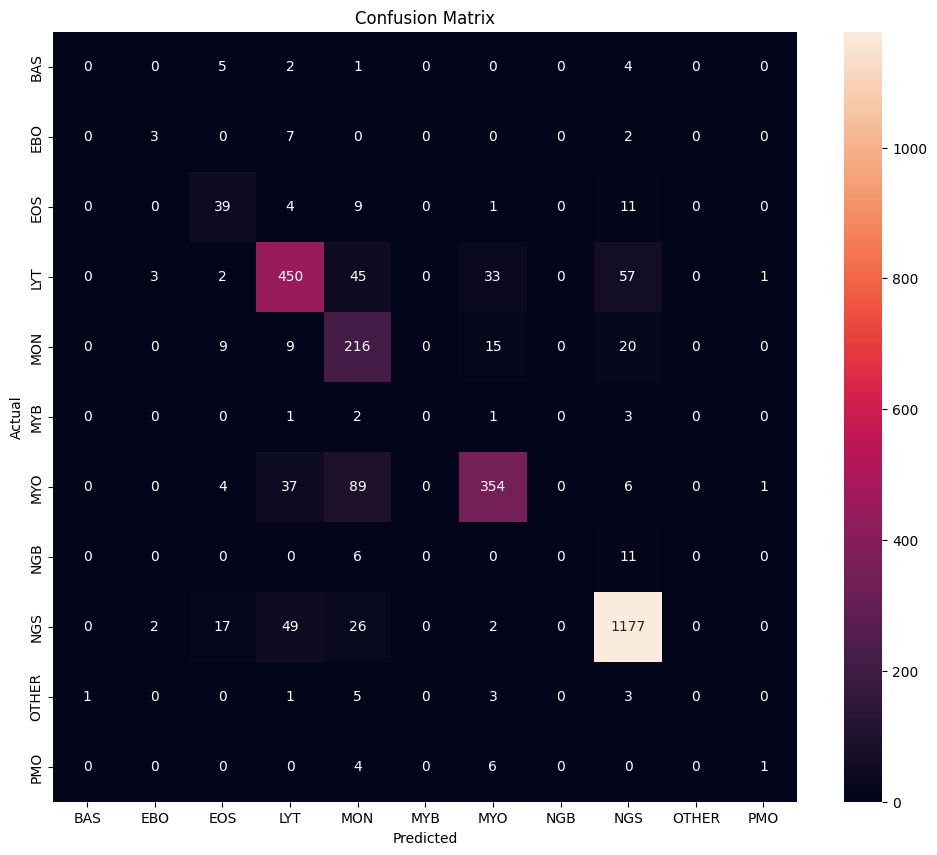

In [33]:
# Generate confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

# Plot confusion matrix
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [34]:
# Import accuracy score
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

# Print accuracy
print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.8115942028985508


In [35]:
# Import recall score
from sklearn.metrics import recall_score

# Calculate recall
recall = recall_score(
    all_labels,
    all_predictions,
    average='weighted'
)

# Print recall
print("Recall:", recall)

Recall: 0.8115942028985508


In [36]:
# Import f1 score
from sklearn.metrics import f1_score

# Calculate F1-score
f1 = f1_score(
    all_labels,
    all_predictions,
    average='weighted'
)

# Print F1-score
print("F1-score:", f1)

F1-score: 0.8068636425091795
